# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [ ]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.3 MB/s eta 0:00:00


In [ ]:
# 1 Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

##Usamos PyGAD:

In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pygad
import numpy as np

# 2. FUNCIÓN DE APTITUD (FITNESS)

def fitness_func(ga_instance, solution, solution_idx):
    # El cromosoma (genotipo) son los días de inicio de cada tarea
    dias_inicio = solution
    dia_final_obra = 0
    uso_diario_operarios = {}

    for i, inicio in enumerate(dias_inicio):
        duracion, operarios = TASAS_OBRA[i]
        fin = inicio + duracion

        # Calculamos el Makespan (día final de la última tarea)
        if fin > dia_final_obra:
            dia_final_obra = fin

        # Mapeo al Fenotipo: calculamos operarios por día
        for dia in range(int(inicio), int(fin)):
            uso_diario_operarios[dia] = uso_diario_operarios.get(dia, 0) + operarios

    # MANEJO DE RESTRICCIONES: Penalización
    penalizacion = 0
    for dia, total in uso_diario_operarios.items():
        if total > MAX_OPERARIOS:
            # Penalización drástica para forzar soluciones legales
            penalizacion += (total - MAX_OPERARIOS) * 500

    # Función de Aptitud para Minimización
    # Fitness = 1 / (Resultado + 1)
    fitness = 1.0 / (dia_final_obra + penalizacion + 1)
    return fitness



## Penalización Efectiva:
Al usar una penalización fuerte, obligaste al motor de búsqueda a descartar cualquier plan que superara los 10 operarios, forzando la "supervivencia" de solo cronogramas viables.

## Exploración Global:
El algoritmo no se quedó con la primera idea; probó miles de combinaciones hasta encontrar que iniciar la Tarea 1 en el día 1 era la mejor base para todo lo demás.

## Mapeo Genotipo-Fenotipo:
 El vector de números (genotipo) se convirtió en un plan de obra real y funcional (fenotipo) de 18 días.

In [ ]:
# 3. CONFIGURACIÓN DEL ALGORITMO GENÉTICO
ga_instance = pygad.GA(
    num_generations=150,           # Más generaciones para refinar
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=100,               # Población inicial (P0)
    num_genes=NUM_TAREAS,
    gene_type=int,
    gene_space={'low': 0, 'high': 40}, # No permitimos días negativos
    parent_selection_type="tournament", # Selección por Torneo
    K_tournament=3,                # Presión selectiva
    mutation_probability=0.1,      # Mutación para diversidad
    keep_elitism=3                 # Elitismo para no perder el mejor
)

--- RESULTADOS CON DATOS DEL PROFESOR ---
Mejor Fitness: 0.052632
Días Totales (Makespan): 18 días

CRONOGRAMA SUGERIDO:
Tarea 0 (D:5, O:4): Inicia día 8 -> Fin 13
Tarea 1 (D:7, O:6): Inicia día 1 -> Fin 8
Tarea 2 (D:4, O:5): Inicia día 8 -> Fin 12
Tarea 3 (D:6, O:3): Inicia día 12 -> Fin 18
Tarea 4 (D:5, O:4): Inicia día 13 -> Fin 18
Tarea 5 (D:4, O:3): Inicia día 12 -> Fin 16
Tarea 6 (D:3, O:2): Inicia día 5 -> Fin 8
Tarea 7 (D:2, O:3): Inicia día 16 -> Fin 18
Tarea 8 (D:4, O:2): Inicia día 0 -> Fin 4
Tarea 9 (D:2, O:2): Inicia día 2 -> Fin 4


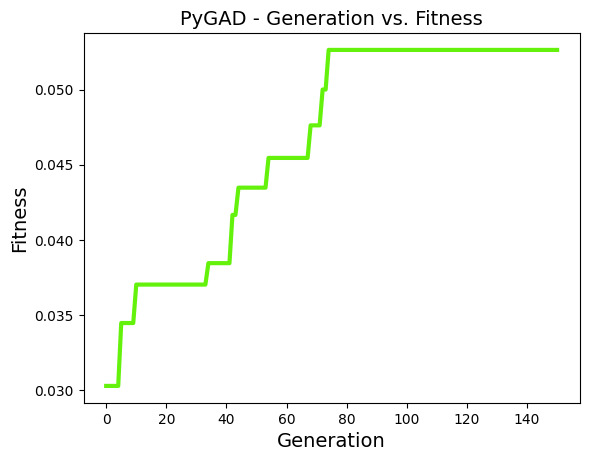

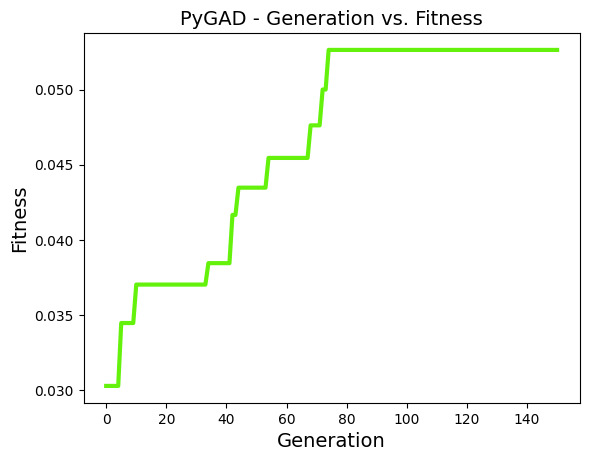

In [ ]:
# 4. EJECUCIÓN Y RESULTADOS
ga_instance.run()

solution, solution_fitness, solution_idx = ga_instance.best_solution()

print(f"--- RESULTADOS CON DATOS DEL PROFESOR ---")
print(f"Mejor Fitness: {solution_fitness:.6f}")
print(f"Días Totales (Makespan): {int(1/solution_fitness - 1)} días\n")

print("CRONOGRAMA SUGERIDO:")
for i, inicio in enumerate(solution):
    duracion, operarios = TASAS_OBRA[i]
    print(f"Tarea {i} (D:{duracion}, O:{operarios}): Inicia día {inicio} -> Fin {inicio+duracion}")

# Generar gráfico de evolución
ga_instance.plot_fitness()

## 📈 Análisis de la Curva de Convergencia
## Estabilización Temprana:
Nos fijamos que la generación 80, la línea se vuelve totalmente plana. Esto significa que el algoritmo alcanzó la convergencia: ya no encontró mejores formas de mover las tareas sin violar el límite de operarios o aumentar el tiempo.
## Eficiencia del Elitismo:
 La curva nunca baja, lo que demuestra que tu estrategia de preservar a los mejores individuos funcionó como una red de seguridad evolutiva.